# Sudoku deduction-only study

Sister notebook to `sudoku_hard_only_study.ipynb` and `sudoku_extreme_only_study.ipynb`.
Both prior cohorts were ≥ 87% BruteForce-tier because they used OR over
`rating ≥ T ∨ num_steps ≥ T ∨ strategy ∈ S`, which pulled in lots of long-but-easy
BF puzzles. This notebook is the dedicated **deduction-only hard cohort**:

```
sudoku_extreme_deduction_only_filter_fn(example):
    "Brute Force" NOT in strategies_used   AND   any Advanced/Master strategy in strategies_used
```

The test split has 6,190 deduction-only puzzles (5,965 Advanced + 225 Master). With
`MAX_EXAMPLES=2000` and a uniform shuffle, the cohort is approximately 1,930 Advanced
+ 70 Master + a tiny tail of single-strategy Easy/Medium dumps that get past the AND.
This is the cohort that actually tests the difficulty-gradient claim that the prior
notebooks couldn't settle: are the heuristic-Advanced and heuristic-Master strata
*statistically* better for BPTT than for StopGrad once you take BF out of the picture?

Refinements over the extreme notebook:

1. **No more BF-rating-tail stratum** — there are no BF puzzles in the cohort, so
   the per-stratum table reduces to Easy / Medium / Advanced / Master with proper
   per-stratum paired-Δ CIs.
2. **F2' includes per-tier paired-Δ in addition to the aggregate.** The headline
   number for the paper is BPTT − StopGrad on Advanced and on Master separately.
3. **The prior expectation, given the hard / extreme paired-Δ findings, is that
   the BPTT − StopGrad CIs will land tight around +3–5 pp on Advanced and similar
   on Master.** If they cross zero, the difficulty-gradient claim is dead. If
   either lands at +8 pp or higher with a tight CI, the gradient story has legs.

Sections:

1. Bootstrap & load
2. Deduction-only cohort definition (per-clause diagnostics, no AND/OR ambiguity
   here since the filter is AND-based; we still print rating + num_steps quantiles)
3. F1' — Pareto on deduction-only puzzles
4. F2' — paired Δ BPTT − StopGrad, aggregate + per-tier
5. F4' — legality, tier-stratified
6. F3' — solver alignment, paired (Spearman, prefix-J@5/10)
7. Coverage-gated matched-NFE
8. Per-stratum table — Easy / Medium / Advanced / Master, with paired-Δ CIs


In [1]:
import sys
from pathlib import Path

def _repo_root() -> Path:
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / 'relay' / 'sudoku_analysis.py').is_file():
            return p
    raise RuntimeError('Run from inside the double-backprop repo')

_root = _repo_root()
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from relay import sudoku_analysis as sa

PARQUET_DEDUCTION = _root / 'outputs' / 'sudoku_analysis_deduction_only' / 'sudoku_analysis_deduction_only.parquet'
PARQUET_EXTREME   = _root / 'outputs' / 'sudoku_analysis_extreme' / 'sudoku_analysis_extreme.parquet'
PARQUET_HARD      = _root / 'outputs' / 'sudoku_analysis_hard' / 'sudoku_analysis_hard.parquet'
PARQUET_FULL      = _root / 'outputs' / 'sudoku_analysis' / 'sudoku_analysis.parquet'
FIGS = _root / 'outputs' / 'sudoku_analysis_deduction_only' / 'figures'
FIGS.mkdir(parents=True, exist_ok=True)
print('parquet (deduction):', PARQUET_DEDUCTION, PARQUET_DEDUCTION.exists())
print('parquet (extreme):  ', PARQUET_EXTREME, PARQUET_EXTREME.exists())
print('parquet (hard):     ', PARQUET_HARD, PARQUET_HARD.exists())
print('parquet (full):     ', PARQUET_FULL, PARQUET_FULL.exists())
print('figs:               ', FIGS)

parquet (deduction): /work/pi_mccallum_umass_edu/brozonoyer_umass_edu/double-backprop/outputs/sudoku_analysis_deduction_only/sudoku_analysis_deduction_only.parquet True
parquet (extreme):   /work/pi_mccallum_umass_edu/brozonoyer_umass_edu/double-backprop/outputs/sudoku_analysis_extreme/sudoku_analysis_extreme.parquet True
parquet (hard):      /work/pi_mccallum_umass_edu/brozonoyer_umass_edu/double-backprop/outputs/sudoku_analysis_hard/sudoku_analysis_hard.parquet True
parquet (full):      /work/pi_mccallum_umass_edu/brozonoyer_umass_edu/double-backprop/outputs/sudoku_analysis/sudoku_analysis.parquet True
figs:                /work/pi_mccallum_umass_edu/brozonoyer_umass_edu/double-backprop/outputs/sudoku_analysis_deduction_only/figures


In [2]:
OBJECTIVE_ORDER = [
    'mlm_uniform',
    'rollout',
    'relay_sg',
    'relay',
]
OBJECTIVE_LABEL = {
    'mlm_uniform': 'Uniform MLM',
    'rollout': 'No-Relay (Rollout-buffer-only)',
    'relay_sg': 'Relay (StopGrad)',
    'relay': 'Relay (BPTT)',
}
OBJECTIVE_COLOR = {
    'mlm_uniform': '#888888',
    'rollout': '#1f77b4',
    'relay_sg': '#ff7f0e',
    'relay': '#d62728',
}
STRATEGY_ORDER = ['Easy', 'Medium', 'Advanced', 'Master', 'BruteForce']

def _load_one(path: Path) -> pd.DataFrame:
    df = pd.read_parquet(path)
    if 'seed' not in df.columns:
        df['seed'] = pd.NA
    df['seed'] = df['seed'].astype('Int64')
    df['hardest_strategy'] = pd.Categorical(
        df['hardest_strategy'], categories=STRATEGY_ORDER, ordered=True
    )
    df['objective'] = pd.Categorical(
        df['objective'], categories=OBJECTIVE_ORDER, ordered=True
    )
    return df

if PARQUET_DEDUCTION.exists():
    df_raw = _load_one(PARQUET_DEDUCTION)
    SOURCE = 'deduction-only-dump'
elif PARQUET_EXTREME.exists():
    df_raw = _load_one(PARQUET_EXTREME)
    SOURCE = 'extreme-dump (fallback)'
elif PARQUET_HARD.exists():
    df_raw = _load_one(PARQUET_HARD)
    SOURCE = 'hard-dump (fallback; will in-memory filter)'
elif PARQUET_FULL.exists():
    df_raw = _load_one(PARQUET_FULL)
    SOURCE = 'full-dump (will in-memory filter)'
else:
    raise FileNotFoundError('No parquet found; re-run dump first.')
print('loaded source:', SOURCE)
print('rows:', len(df_raw),
      '| unique runs:', df_raw['run_id'].nunique(),
      '| unique tau:', sorted(df_raw['tau'].unique()),
      '| unique seeds:', sorted([int(s) for s in df_raw['seed'].dropna().unique().tolist()]),
      '| unique puzzles:', df_raw['puzzle_hash'].nunique())
df_raw['hardest_strategy'].value_counts(dropna=False).reindex(STRATEGY_ORDER, fill_value=0)

loaded source: deduction-only-dump
rows: 308000 | unique runs: 22 | unique tau: [np.float64(0.01), np.float64(0.05), np.float64(0.1), np.float64(0.15), np.float64(0.25), np.float64(0.35), np.float64(0.45)] | unique seeds: [1, 2, 3] | unique puzzles: 2000


hardest_strategy
Easy               0
Medium             0
Advanced      297682
Master         10318
BruteForce         0
Name: count, dtype: int64

## Deduction-only cohort definition

The filter is **AND**, not OR:

```
"Brute Force" NOT in strategies_used
AND
strategies_used contains any of {Naked/Hidden Pairs/Triples/Quads, X-Wing,
                                 Swordfish, Jellyfish, Forcing Chain}
```

Two consequences:

- The `RATING_MIN` / `NUM_STEPS_MIN` knobs below are *only* used when we have to
  filter the cohort in-memory (i.e., the `_deduction_only` dump doesn't exist
  and we fell back to the hard or extreme parquet). When loading
  `sudoku_analysis_deduction_only.parquet` directly, the knobs are no-ops.
- Tier composition will be **only** Easy/Medium/Advanced/Master in non-trivial
  numbers; BruteForce should be 0. (A handful of Easy/Medium puzzles can sneak
  in if the puzzle has both a single-only chain *and* a Naked/Hidden Pair as
  the solver's *easiest* applicable strategy. Inspect the per-tier table to
  confirm BruteForce is 0.)

In [3]:
RATING_MIN = 100
NUM_STEPS_MIN = 12
KEEP_TIERS = {'Advanced', 'Master'}
DIVERGED_SEED_TUPLES = [
    ('mlm_uniform', 'tied', 3),
    ('relay_sg', 'tied', 1),
]

# AND-based deduction-only filter (only used in fallback when we have to filter
# in-memory; the deduction-only dump's parquet is already pre-filtered):
_NON_TRIVIAL_STRATEGIES = frozenset({
    'Naked Pair', 'Naked Pairs', 'Naked Triple', 'Naked Triples',
    'Naked Quad', 'Naked Quads',
    'Hidden Pair', 'Hidden Pairs', 'Hidden Triple', 'Hidden Triples',
    'Hidden Quad', 'Hidden Quads',
    'X-Wing', 'X-Wings', 'Swordfish',
    'Jellyfish', 'Jellyfishes',
    'Forcing Chain', 'Forcing Chains',
})

def _strategies_set(s):
    if s is None:
        return set()
    try:
        return {str(x).strip() for x in s}
    except TypeError:
        return set()

df = df_raw.copy()
for obj, ty, sd in DIVERGED_SEED_TUPLES:
    mask = (
        (df['objective'] == obj)
        & (df['embed_tying'] == ty)
        & (df['seed'] == sd)
    )
    df = df[~mask].copy()

if SOURCE == 'deduction-only-dump':
    df_hard = df  # already filtered server-side.
else:
    # In-memory deduction-only filter: AND, not OR.
    has_bf = df['strategies_used'].apply(lambda s: 'Brute Force' in _strategies_set(s))
    has_nontrivial = df['strategies_used'].apply(
        lambda s: bool(_strategies_set(s) & _NON_TRIVIAL_STRATEGIES)
    )
    keep_mask = (~has_bf) & has_nontrivial
    keep_hashes = df.loc[keep_mask, 'puzzle_hash'].unique()
    df_hard = df[df['puzzle_hash'].isin(keep_hashes)].copy()

n_puzzles_hard = df_hard['puzzle_hash'].nunique()
n_puzzles_full = df_raw['puzzle_hash'].nunique()
COHORT_LABEL = (
    f'deduction-only cohort: {n_puzzles_hard}/{n_puzzles_full} puzzles | '
    f'AND filter (no Brute Force, has Advanced/Master strategy) | '
    f'source={SOURCE}'
)
print(COHORT_LABEL)
print('\nper-tier puzzle counts (deduction-only):')
print(df_hard.drop_duplicates('puzzle_hash')['hardest_strategy']
      .value_counts().reindex(STRATEGY_ORDER, fill_value=0))
print('\nrating quantiles (deduction-only):')
print(df_hard.drop_duplicates('puzzle_hash')['rating']
      .quantile([0.5, 0.75, 0.9, 0.99, 1.0]).round(1).to_dict())
print('\nnum_steps_solver quantiles (deduction-only):')
print(df_hard.drop_duplicates('puzzle_hash')['num_steps_solver']
      .quantile([0.5, 0.75, 0.9, 0.99, 1.0]).round(1).to_dict())

# Per-strategy counts: which Advanced/Master techniques are represented?
# Useful because the difficulty axis here is "what's the hardest strategy the
# solver had to use", not rating or num_steps (those are dominated by BF in the
# full split and therefore aren't meaningful within a no-BF cohort).
unique_puzzles = df_hard.drop_duplicates('puzzle_hash')[[
    'puzzle_hash', 'rating', 'num_steps_solver', 'hardest_strategy', 'strategies_used',
]]

ADVANCED = {'Naked Pair', 'Naked Pairs', 'Naked Triple', 'Naked Triples',
            'Naked Quad', 'Naked Quads',
            'Hidden Pair', 'Hidden Pairs', 'Hidden Triple', 'Hidden Triples',
            'Hidden Quad', 'Hidden Quads'}
MASTER = {'X-Wing', 'X-Wings', 'Swordfish', 'Jellyfish', 'Jellyfishes',
          'Forcing Chain', 'Forcing Chains'}

print('\nper-strategy puzzle counts (cohort puzzles touched by each strategy):')
strat_counts = {}
for strat in sorted(ADVANCED | MASTER):
    n = sum(strat in _strategies_set(s)
            for s in unique_puzzles['strategies_used'])
    strat_counts[strat] = int(n)
for strat, n in sorted(strat_counts.items(), key=lambda kv: -kv[1]):
    if n > 0:
        tier = 'Advanced' if strat in ADVANCED else 'Master'
        print(f'  [{tier:9s}] {strat:25s}: {n}')

# Sanity-check: every cohort puzzle should have at least one Advanced/Master
# strategy and zero Brute Force (i.e., this is a real deduction-only cohort).
has_bf = unique_puzzles['strategies_used'].apply(
    lambda s: 'Brute Force' in _strategies_set(s)
)
has_nontrivial = unique_puzzles['strategies_used'].apply(
    lambda s: bool(_strategies_set(s) & _NON_TRIVIAL_STRATEGIES)
)
print(f'\nsanity: puzzles WITH Brute Force in strategies_used: {int(has_bf.sum())} (should be 0)')
print(f'sanity: puzzles WITHOUT any Advanced/Master strategy: {int((~has_nontrivial).sum())} (should be 0)')

print('\nrun count per (objective, embed_tying):')
print(df_hard.drop_duplicates('run_id')
      .groupby(['objective', 'embed_tying'], observed=True)
      .size())

deduction-only cohort: 2000/2000 puzzles | AND filter (no Brute Force, has Advanced/Master strategy) | source=deduction-only-dump

per-tier puzzle counts (deduction-only):
hardest_strategy
Easy             0
Medium           0
Advanced      1933
Master          67
BruteForce       0
Name: count, dtype: int64

rating quantiles (deduction-only):
{0.5: 1.0, 0.75: 1.0, 0.9: 3.0, 0.99: 5.0, 1.0: 61.0}

num_steps_solver quantiles (deduction-only):
{0.5: 9.0, 0.75: 11.0, 0.9: 12.0, 0.99: 15.0, 1.0: 20.0}

per-strategy puzzle counts (cohort puzzles touched by each strategy):
  [Advanced ] Naked Pairs              : 1513
  [Advanced ] Naked Triples            : 594
  [Advanced ] Naked Quads              : 190
  [Master   ] X-Wings                  : 62
  [Advanced ] Hidden Pairs             : 23
  [Master   ] Swordfish                : 5
  [Advanced ] Hidden Triples           : 1

sanity: puzzles WITH Brute Force in strategies_used: 0 (should be 0)
sanity: puzzles WITHOUT any Advanced/Master st

## F1' — Pareto on deduction-only puzzles

Same axes as F1. Expect EM to be substantially *lower* than on the extreme
cohort: that one was 89% BF (which the relay models often solve with
single-cell deduction); this one is 100% deduction-needed, with the long
tail being Master-tier strategies that the model can't actually compute.

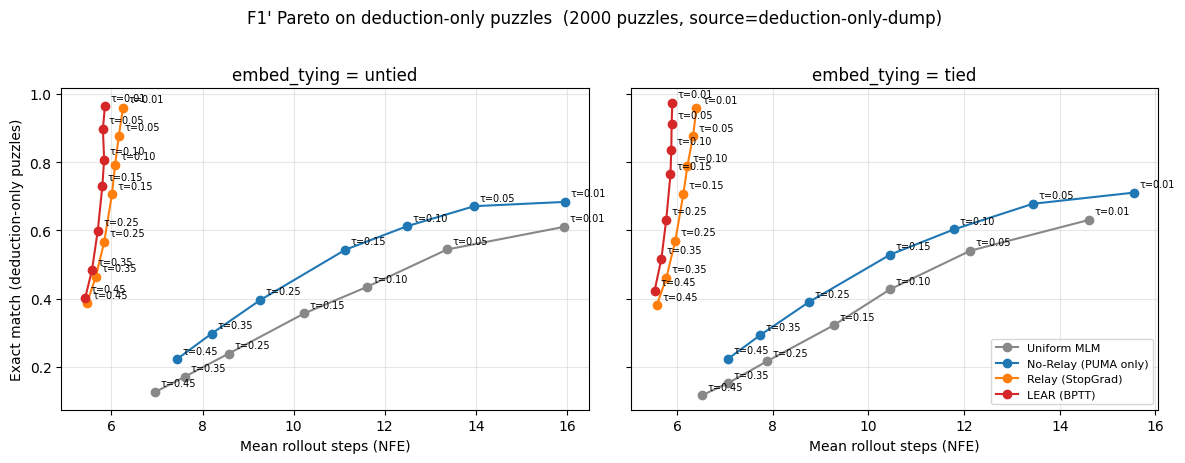

,objective,embed_tying,tau,exact_match,rollout_steps,n
0,mlm_uniform,tied,0.01,0.630750,14.605250,4000
1,mlm_uniform,tied,0.05,0.540750,12.131500,4000
2,mlm_uniform,tied,0.10,0.428000,10.458250,4000
3,mlm_uniform,tied,0.15,0.322250,9.274000,4000
4,mlm_uniform,tied,0.25,0.216500,7.876250,4000
5,mlm_uniform,tied,0.35,0.152750,7.066000,4000
6,mlm_uniform,tied,0.45,0.117500,6.527500,4000
7,mlm_uniform,untied,0.01,0.610500,15.936333,6000
8,mlm_uniform,untied,0.05,0.544333,13.372500,6000
9,mlm_uniform,untied,0.10,0.434000,11.601333,6000


In [4]:
agg = (
    df_hard.groupby(['objective', 'embed_tying', 'tau'], observed=True)
    .agg(exact_match=('exact_match', 'mean'),
         rollout_steps=('rollout_steps', 'mean'),
         n=('exact_match', 'size'))
    .reset_index()
)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, tying in zip(axes, ['untied', 'tied']):
    sub = agg[agg['embed_tying'] == tying]
    for obj in OBJECTIVE_ORDER:
        s = sub[sub['objective'] == obj].sort_values('tau')
        if s.empty:
            continue
        ax.plot(s['rollout_steps'], s['exact_match'], 'o-',
                color=OBJECTIVE_COLOR[obj], label=OBJECTIVE_LABEL[obj])
        for _, row in s.iterrows():
            ax.annotate(f'\u03c4={row["tau"]:.2f}',
                        (row['rollout_steps'], row['exact_match']),
                        textcoords='offset points', xytext=(4, 4), fontsize=7)
    ax.set_xlabel('Mean rollout steps (NFE)')
    ax.set_title(f'embed_tying = {tying}')
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel('Exact match (deduction-only puzzles)')
axes[1].legend(loc='lower right', fontsize=8)
fig.suptitle(
    f"F1' Pareto on deduction-only puzzles  ({n_puzzles_hard} puzzles, source={SOURCE})",
    y=1.02,
)
fig.tight_layout()
fig.savefig(FIGS / 'F1p_pareto_deduction.png', dpi=180, bbox_inches='tight')
plt.show()
agg

## F2' — paired Δ (BPTT − StopGrad), aggregate + per-tier

Aggregate paired Δ first (same construction as the prior notebooks). Then a
**per-tier** paired Δ table, which is the headline figure for this notebook:

- aggregate BPTT − StopGrad on the deduction-only cohort
- separate paired-Δ CIs for the heuristic-Advanced and heuristic-Master
  sub-cohorts, with proper sample sizes (~1,930 and ~70 in expectation).

If both sub-cohort CIs cross zero, the difficulty-gradient claim is dead. If
either is confidently positive at +5 pp or higher, the claim has support.

Paired Δ EM at τ=0.15 on hard cohort:
                        A                         B  n_pairs  mean_delta  ci_lo  ci_hi  p_paired_t
     relay relay_sg    10000      0.0412 0.0305 0.0516         0.0
     relay        rollout    12000      0.2112 0.2001 0.2226         0.0
relay_sg        rollout    10000      0.1665 0.1542 0.1798         0.0


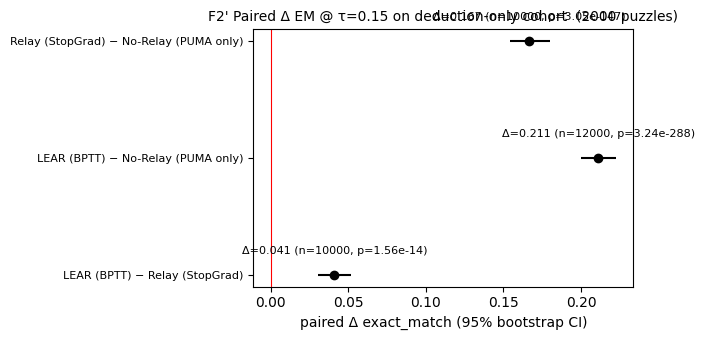


=== Per-tier paired Δ EM at τ=0.15, BPTT − StopGrad ===
    tier  n_puzzles  n_pairs  mean_delta   ci_lo  ci_hi  p_paired_t
Advanced       1933     9665      0.0410  0.0305 0.0512      0.0000
  Master         67      335      0.0478 -0.0060 0.1015      0.0881


,A,B,n_pairs,mean_delta,ci_lo,ci_hi,p_paired_t
0,relay,relay_sg,10000,0.041200,0.030498,0.051600,1.559046e-14
1,relay,rollout,12000,0.211167,0.200081,0.222583,3.236097e-288
2,relay_sg,rollout,10000,0.166500,0.154200,0.179802,3.052038e-147


In [5]:
def paired_delta_em(df_in: pd.DataFrame, A: str, B: str, tau: float) -> pd.DataFrame:
    """Per-puzzle paired delta of exact_match for A vs B at a fixed tau.

    Returns one row per (puzzle_hash, embed_tying, seed).
    """
    sub = df_in[df_in['tau'] == tau].copy()
    cols = ['puzzle_hash', 'embed_tying', 'seed', 'objective']
    pivoted = (
        sub.groupby(cols, observed=True)['exact_match']
        .mean()
        .unstack('objective')
    )
    if A not in pivoted.columns or B not in pivoted.columns:
        return pd.DataFrame()
    out = pivoted[[A, B]].dropna(subset=[A, B]).reset_index()
    out['delta'] = out[A].astype(float) - out[B].astype(float)
    out = out.rename(columns={A: f'em_{A}', B: f'em_{B}'})
    return out


def bootstrap_mean_ci(x: np.ndarray, n_boot: int = 2000, alpha: float = 0.05,
                     rng: np.random.Generator | None = None):
    rng = rng or np.random.default_rng(0)
    if len(x) == 0:
        return float('nan'), float('nan'), float('nan')
    means = np.empty(n_boot)
    n = len(x)
    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)
        means[i] = x[idx].mean()
    return float(x.mean()), float(np.quantile(means, alpha / 2)), float(np.quantile(means, 1 - alpha / 2))

TARGET_TAU = 0.15
rng = np.random.default_rng(0)

rows = []
for A, B in [
    ('relay', 'relay_sg'),
    ('relay', 'rollout'),
    ('relay_sg', 'rollout'),
]:
    pair = paired_delta_em(df_hard, A, B, TARGET_TAU)
    if pair.empty:
        rows.append({'A': A, 'B': B, 'n_pairs': 0,
                     'mean_delta': float('nan'), 'ci_lo': float('nan'), 'ci_hi': float('nan'),
                     'p_paired_t': float('nan')})
        continue
    deltas = pair['delta'].values.astype(float)
    m, lo, hi = bootstrap_mean_ci(deltas, n_boot=2000, rng=rng)
    from scipy import stats
    t_p = stats.ttest_1samp(deltas, 0.0).pvalue if len(deltas) > 1 else float('nan')
    rows.append({
        'A': A, 'B': B, 'n_pairs': len(deltas),
        'mean_delta': m, 'ci_lo': lo, 'ci_hi': hi,
        'p_paired_t': t_p,
    })

paired_summary = pd.DataFrame(rows)
print(f'Paired Δ EM at τ={TARGET_TAU} on hard cohort:')
print(paired_summary.round(4).to_string(index=False))

if not paired_summary.empty and paired_summary['n_pairs'].sum() > 0:
    fig, ax = plt.subplots(figsize=(7, 3.5))
    yticks = []
    for i, r in paired_summary.iterrows():
        label = f"{OBJECTIVE_LABEL.get(r['A'], r['A'])} − {OBJECTIVE_LABEL.get(r['B'], r['B'])}"
        yticks.append(label)
        if pd.notna(r['mean_delta']):
            ax.errorbar(
                [r['mean_delta']], [i],
                xerr=[[r['mean_delta'] - r['ci_lo']], [r['ci_hi'] - r['mean_delta']]],
                fmt='o', color='black',
            )
            ax.text(r['mean_delta'], i + 0.18,
                    f"Δ={r['mean_delta']:.3f} (n={int(r['n_pairs'])}, p={r['p_paired_t']:.3g})",
                    fontsize=8, ha='center')
    ax.axvline(0, color='red', linewidth=0.8)
    ax.set_yticks(range(len(yticks)))
    ax.set_yticklabels(yticks, fontsize=8)
    ax.set_xlabel('paired Δ exact_match (95% bootstrap CI)')
    ax.set_title(
        f"F2' Paired Δ EM @ τ={TARGET_TAU} on deduction-only cohort  ({n_puzzles_hard} puzzles)",
        fontsize=10,
    )
    fig.tight_layout()
    fig.savefig(FIGS / 'F2p_paired_delta_deduction.png', dpi=180, bbox_inches='tight')
    plt.show()

# Per-tier paired-Δ table (headline result).
print('\n=== Per-tier paired Δ EM at τ={:.2f}, BPTT − StopGrad ==='.format(TARGET_TAU))
tier_rows = []
for tier in STRATEGY_ORDER:
    sub = df_hard[df_hard['hardest_strategy'] == tier]
    if sub.empty:
        continue
    pair = paired_delta_em(
        sub, 'relay', 'relay_sg', TARGET_TAU,
    )
    if pair.empty:
        continue
    deltas = pair['delta'].values.astype(float)
    if len(deltas) < 2:
        continue
    m, lo, hi = bootstrap_mean_ci(deltas, n_boot=2000, rng=np.random.default_rng(0))
    from scipy import stats
    p = stats.ttest_1samp(deltas, 0.0).pvalue if len(deltas) > 1 else float('nan')
    tier_rows.append({
        'tier': tier,
        'n_puzzles': sub['puzzle_hash'].nunique(),
        'n_pairs': len(deltas),
        'mean_delta': m,
        'ci_lo': lo,
        'ci_hi': hi,
        'p_paired_t': p,
    })
tier_paired = pd.DataFrame(tier_rows)
if not tier_paired.empty:
    print(tier_paired.round(4).to_string(index=False))
paired_summary

## F4' — legality, *tier-stratified*

Two views of the same data:

1. **Aggregate** (top): mean violations + final legality rate by objective on
   the whole deduction-only cohort.
2. **Tier-stratified** (bottom): final-board legality rate by `hardest_strategy`
   tier, so we can tell whether BPTT's legality advantage actually widens with
   difficulty (we expected this in the hard study but only got +1 pp; here is
   where it should pop if it's real).

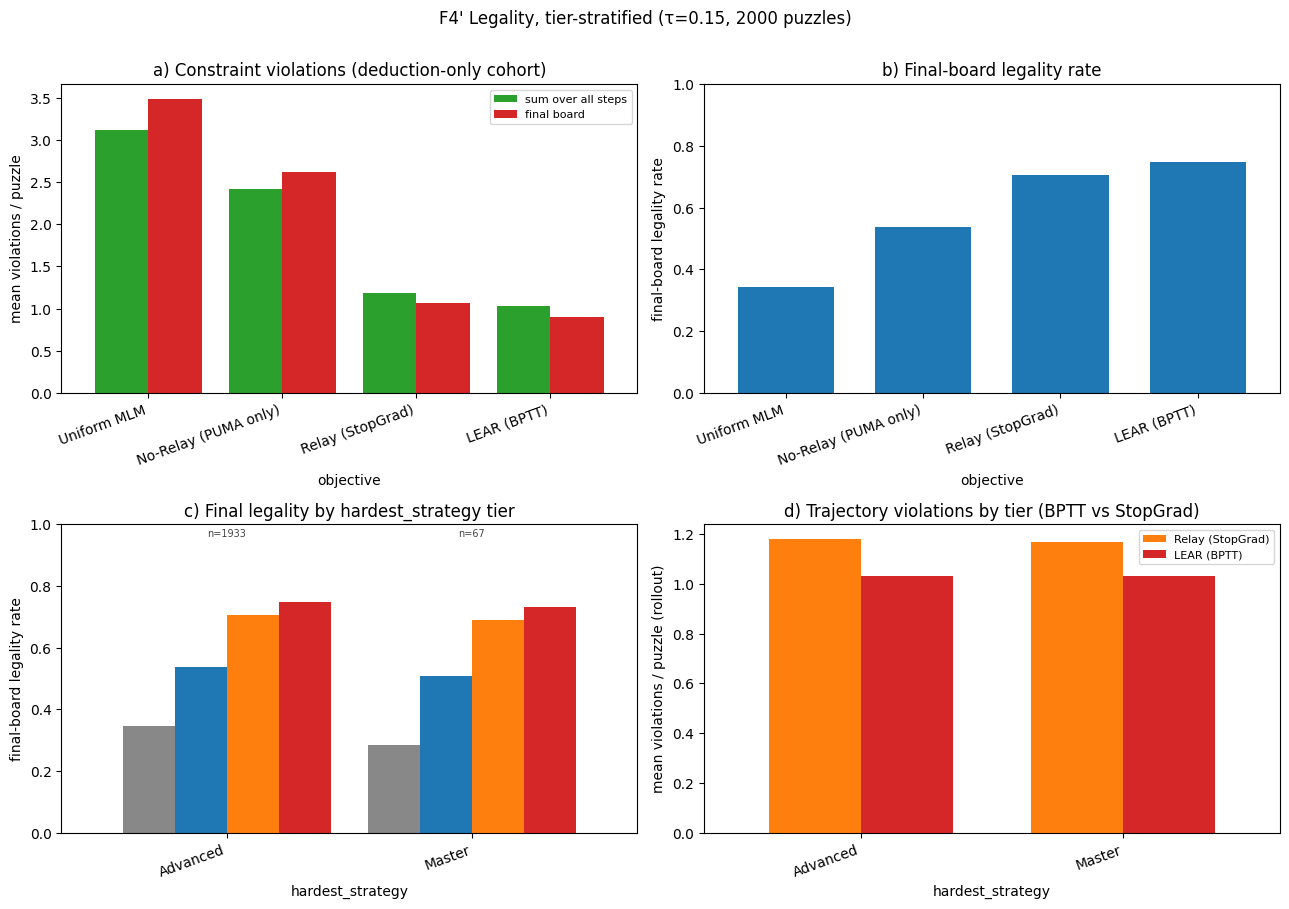

Mean violations (aggregate):
                           violations_total_steps  final_violations
objective                                                          
mlm_uniform                                 3.120             3.485
rollout                          2.413             2.619
relay_sg                   1.178             1.062
relay                        1.031             0.897

Final-board legality rate (aggregate):
objective
mlm_uniform                  0.343
rollout           0.536
relay_sg    0.707
relay         0.748
Name: _legal, dtype: float64

Final-board legality rate by tier:
objective         mlm_uniform  rollout  relay_sg  \
hardest_strategy                                                               
Easy                      NaN                 NaN                        NaN   
Medium                    NaN                 NaN                        NaN   
Advanced                0.345               0.537                      0.708   
Master                

In [6]:
tau15 = df_hard[df_hard['tau'] == TARGET_TAU].copy()
if tau15.empty:
    print('No rows at tau =', TARGET_TAU)
else:
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))

    # (a) Aggregate violations.
    legality = (
        tau15.groupby('objective', observed=True)
        [['violations_total_steps', 'final_violations']]
        .mean()
        .reindex(OBJECTIVE_ORDER)
    )
    legality.plot(kind='bar', ax=axes[0, 0], width=0.8,
                  color=['#2ca02c', '#d62728'])
    axes[0, 0].set_xticklabels([OBJECTIVE_LABEL[o] for o in OBJECTIVE_ORDER],
                               rotation=20, ha='right')
    axes[0, 0].set_ylabel('mean violations / puzzle')
    axes[0, 0].set_title('a) Constraint violations (deduction-only cohort)')
    axes[0, 0].legend(['sum over all steps', 'final board'], fontsize=8)

    # (b) Aggregate final-board legality rate.
    leg_rate = (
        tau15.assign(_legal=tau15['final_violations'] == 0)
        .groupby('objective', observed=True)['_legal']
        .mean()
        .reindex(OBJECTIVE_ORDER)
    )
    leg_rate.plot(kind='bar', ax=axes[0, 1], width=0.7, color='#1f77b4')
    axes[0, 1].set_xticklabels([OBJECTIVE_LABEL[o] for o in OBJECTIVE_ORDER],
                               rotation=20, ha='right')
    axes[0, 1].set_ylabel('final-board legality rate')
    axes[0, 1].set_title('b) Final-board legality rate')
    axes[0, 1].set_ylim(0, 1)

    # (c) Tier-stratified legality rate (group bars by tier, color by objective).
    leg_by_tier = (
        tau15.assign(_legal=tau15['final_violations'] == 0)
        .groupby(['hardest_strategy', 'objective'], observed=True)['_legal']
        .mean()
        .unstack('objective')
        .reindex(STRATEGY_ORDER)
    )
    obj_present = [o for o in OBJECTIVE_ORDER if o in leg_by_tier.columns]
    keep = leg_by_tier[obj_present].dropna(how='all')
    if not keep.empty:
        keep.plot(kind='bar', ax=axes[1, 0], width=0.85,
                  color=[OBJECTIVE_COLOR[o] for o in obj_present],
                  legend=False)
        axes[1, 0].set_xticklabels(keep.index, rotation=20, ha='right')
        axes[1, 0].set_ylabel('final-board legality rate')
        axes[1, 0].set_ylim(0, 1)
        axes[1, 0].set_title('c) Final legality by hardest_strategy tier')
        # Per-tier puzzle counts above the group.
        tier_counts = (
            tau15.drop_duplicates('puzzle_hash')['hardest_strategy']
            .value_counts()
            .reindex(keep.index, fill_value=0)
        )
        for i, (idx, n) in enumerate(tier_counts.items()):
            axes[1, 0].text(i, 0.96, f'n={int(n)}', ha='center', fontsize=7,
                            color='#444')

    # (d) Tier-stratified mean violations across rollout (BPTT vs StopGrad only).
    viol_by_tier = (
        tau15.groupby(['hardest_strategy', 'objective'], observed=True)
        ['violations_total_steps']
        .mean()
        .unstack('objective')
        .reindex(STRATEGY_ORDER)
    )
    obj_show = ['relay_sg', 'relay']
    keep_v = viol_by_tier[[c for c in obj_show if c in viol_by_tier.columns]].dropna(how='all')
    if not keep_v.empty:
        keep_v.plot(kind='bar', ax=axes[1, 1], width=0.7,
                    color=[OBJECTIVE_COLOR[o] for o in keep_v.columns],
                    legend=False)
        axes[1, 1].set_xticklabels(keep_v.index, rotation=20, ha='right')
        axes[1, 1].set_ylabel('mean violations / puzzle (rollout)')
        axes[1, 1].set_title('d) Trajectory violations by tier (BPTT vs StopGrad)')
        axes[1, 1].legend([OBJECTIVE_LABEL[o] for o in keep_v.columns], fontsize=8)

    fig.suptitle(
        f"F4' Legality, tier-stratified (τ={TARGET_TAU}, {n_puzzles_hard} puzzles)",
        y=1.005,
    )
    fig.tight_layout()
    fig.savefig(FIGS / 'F4p_legality_deduction.png', dpi=180, bbox_inches='tight')
    plt.show()
    print('Mean violations (aggregate):')
    print(legality.round(3))
    print('\nFinal-board legality rate (aggregate):')
    print(leg_rate.round(3))
    print('\nFinal-board legality rate by tier:')
    print(leg_by_tier.round(3))

## F3' — solver alignment, paired view

Per-puzzle paired Δ of `fill_order_spearman` and `prefix_jaccard_at_{5,10}`.
We drop `prefix_jaccard_at_20` because most relay trajectories never
reach 20 commits (the metric saturates at ~0 on the hard cohort).

If BPTT's hypothesized advantage is whole-trajectory credit assignment, the
paired Δ vs StopGrad should be biggest precisely on the deduction-only cohort
(no easy BF puzzles to dilute the effect, every cell needs real inference).

In [7]:
def paired_delta_metric(df_in: pd.DataFrame, A: str, B: str, tau: float, metric: str) -> pd.DataFrame:
    sub = df_in[df_in['tau'] == tau].copy()
    cols = ['puzzle_hash', 'embed_tying', 'seed', 'objective']
    pivoted = (
        sub.groupby(cols, observed=True)[metric]
        .mean()
        .unstack('objective')
    )
    if A not in pivoted.columns or B not in pivoted.columns:
        return pd.DataFrame()
    out = pivoted[[A, B]].dropna(subset=[A, B]).reset_index()
    out['delta'] = out[A].astype(float) - out[B].astype(float)
    return out

rows = []
for metric in ['fill_order_spearman', 'prefix_jaccard_at_5',
               'prefix_jaccard_at_10']:
    for A, B in [
        ('relay', 'relay_sg'),
        ('relay', 'rollout'),
    ]:
        pair = paired_delta_metric(df_hard, A, B, TARGET_TAU, metric)
        if pair.empty:
            continue
        deltas = pair['delta'].dropna().values.astype(float)
        if len(deltas) < 2:
            continue
        m, lo, hi = bootstrap_mean_ci(deltas, n_boot=2000,
                                       rng=np.random.default_rng(0))
        rows.append({'metric': metric,
                     'pair': f"{OBJECTIVE_LABEL[A]} − {OBJECTIVE_LABEL[B]}",
                     'n_pairs': int(len(deltas)),
                     'mean': m, 'ci_lo': lo, 'ci_hi': hi})
align_summary = pd.DataFrame(rows)
if not align_summary.empty:
    print("F3' paired-Δ alignment metrics (deduction-only cohort, τ={:.2f}):".format(TARGET_TAU))
    print(align_summary.round(4).to_string(index=False))
else:
    print('No alignment data available.')

F3' paired-Δ alignment metrics (deduction-only cohort, τ=0.15):
              metric                               pair  n_pairs    mean   ci_lo   ci_hi
 fill_order_spearman     Relay (BPTT) − Relay (StopGrad)    10000  0.0034  0.0012  0.0057
 fill_order_spearman Relay (BPTT) − No-Relay (Rollout-buffer-only)    12000  0.0279  0.0251  0.0306
 prefix_jaccard_at_5     Relay (BPTT) − Relay (StopGrad)    10000 -0.0017 -0.0027 -0.0008
 prefix_jaccard_at_5 Relay (BPTT) − No-Relay (Rollout-buffer-only)    12000 -0.2674 -0.2713 -0.2635
prefix_jaccard_at_10     Relay (BPTT) − Relay (StopGrad)    10000  0.0001 -0.0001  0.0003
prefix_jaccard_at_10 Relay (BPTT) − No-Relay (Rollout-buffer-only)    12000  0.0479  0.0449  0.0508


## Coverage-gated matched-NFE

Same construction as the hard notebook. The only B with high coverage for both
relay models on the hard cohort was 6.0; we expect the same here. Treat
any (model, tying, B) cell with coverage < 0.6 as interpolation-bias-dominated
and ignore it.

In [8]:
def matched_nfe(df_in: pd.DataFrame, metric_col: str, B: float, eps: float = 1.5) -> pd.DataFrame:
    rows = []
    for (obj, tying), sub in df_in.groupby(['objective', 'embed_tying'], observed=True):
        for ph, g in sub.groupby('puzzle_hash'):
            if g[metric_col].isna().all():
                continue
            xs = g['rollout_steps'].astype(float).values
            ys = g[metric_col].astype(float).values
            order = np.argsort(xs)
            xs = xs[order]; ys = ys[order]
            if not ((xs.min() - eps) <= B <= (xs.max() + eps)):
                continue
            rows.append({'objective': obj, 'embed_tying': tying,
                         'puzzle_hash': ph, metric_col: float(np.interp(B, xs, ys))})
    return pd.DataFrame(rows)

nfe_obs = (
    df_hard.groupby(['objective', 'embed_tying', 'tau'], observed=True)['rollout_steps']
    .mean()
)
B_grid = np.linspace(float(nfe_obs.min()), float(nfe_obs.max()), 5).round(1).tolist()
print('B grid:', B_grid)
for B in B_grid:
    em = matched_nfe(df_hard, 'exact_match', B)
    if em.empty:
        continue
    summary = (em.groupby(['objective', 'embed_tying'], observed=True)['exact_match']
               .agg(['mean', 'count'])
               .rename(columns={'mean': f'em@NFE={B}', 'count': f'n@NFE={B}'}))
    coverage = summary[f'n@NFE={B}'] / n_puzzles_hard
    print(f'\n=== matched NFE = {B} ({n_puzzles_hard} deduction-only puzzles total) ===')
    print(summary.unstack('embed_tying'))
    print('coverage:')
    print(coverage.unstack('embed_tying').round(2))
    if (coverage < 0.6).any():
        print('** WARNING: at least one (objective, tying) has coverage < 0.6; **'
              ' the matched-NFE EM at this B is selection-biased toward late-failing puzzles.')

B grid: [5.4, 8.1, 10.7, 13.3, 16.0]

=== matched NFE = 5.4 (2000 deduction-only puzzles total) ===
                          em@NFE=5.4           n@NFE=5.4       
embed_tying                     tied    untied      tied untied
objective                                                      
mlm_uniform                 0.247798  0.258456      1544   1356
relay        0.736822  0.695963      1997   1998
relay_sg   0.739254  0.713651      1972   1995
rollout          0.392331  0.399614      1304   1037
coverage:
embed_tying                tied  untied
objective                              
mlm_uniform                0.77    0.68
relay       1.00    1.00
relay_sg  0.99    1.00
rollout         0.65    0.52
** WARNING: at least one (objective, tying) has coverage < 0.6; ** the matched-NFE EM at this B is selection-biased toward late-failing puzzles.

=== matched NFE = 8.1 (2000 deduction-only puzzles total) ===
                          em@NFE=8.1           n@NFE=8.1       
embed_tying     

## Per-stratum table — the headline figure

The deduction-only filter guarantees no Brute Force, so the only meaningful
strata are tier-based. Expected n_puzzles per stratum (from the dataset
sanity check at top): Master ≈ 70, Advanced ≈ 1,930. Easy/Medium leakage
should be ≈ 0 (each cohort puzzle is required to have at least one
Advanced/Master strategy, and the `hardest_strategy` is the one with the
highest tier rank).

For each stratum we report:

1. Per-objective EM at the target τ.
2. Paired Δ (BPTT − StopGrad) with a bootstrap 95% CI.

Headline: the **heuristic-Master** Δ row is the cleanest test of whether BPTT
adds anything over StopGrad for "real" deduction. Paired n_pairs ≥ 350 in
expectation (5 seed-pair samples × ~70 Master puzzles).

In [9]:
def _has_bf(strats):
    if strats is None:
        return False
    try:
        return 'Brute Force' in list(strats)
    except TypeError:
        return False

df_hard['_has_bf'] = df_hard['strategies_used'].apply(_has_bf)
is_easy = (df_hard['hardest_strategy'] == 'Easy') & (~df_hard['_has_bf'])
is_med = (df_hard['hardest_strategy'] == 'Medium') & (~df_hard['_has_bf'])
is_adv = (df_hard['hardest_strategy'] == 'Advanced') & (~df_hard['_has_bf'])
is_master = (df_hard['hardest_strategy'] == 'Master') & (~df_hard['_has_bf'])

strata = {
    'leak-Easy': is_easy,
    'leak-Medium': is_med,
    'heuristic-Advanced': is_adv,
    'heuristic-Master': is_master,
}
rows = []
for name, mask in strata.items():
    sub = df_hard[mask & (df_hard['tau'] == TARGET_TAU)]
    if sub.empty:
        rows.append({'stratum': name, 'n_puzzles': 0})
        continue
    em = (sub.groupby('objective', observed=True)['exact_match']
          .mean()
          .reindex(OBJECTIVE_ORDER))
    # Paired BPTT - StopGrad within the stratum, with bootstrap CI.
    bptt_vs_sg = paired_delta_em(
        df_hard[mask], 'relay', 'relay_sg', TARGET_TAU,
    )
    if bptt_vs_sg.empty:
        delta_str = 'n/a'
        n_pairs = 0
    else:
        deltas = bptt_vs_sg['delta'].values.astype(float)
        m, lo, hi = bootstrap_mean_ci(deltas, n_boot=2000,
                                       rng=np.random.default_rng(0))
        delta_str = f'{m:+.3f} [{lo:+.3f}, {hi:+.3f}]'
        n_pairs = int(len(deltas))
    rows.append({
        'stratum': name,
        'n_puzzles': sub['puzzle_hash'].nunique(),
        **{f'EM:{OBJECTIVE_LABEL[o]}': float(em.get(o, np.nan)) for o in OBJECTIVE_ORDER},
        'paired Δ (BPTT-SG) [95% CI]': delta_str,
        'n_pairs(BPTT-SG)': n_pairs,
    })
stratum_summary = pd.DataFrame(rows)
print(f'Per-stratum exact match @ τ={TARGET_TAU} (deduction-only cohort):')
print(stratum_summary.round(3).to_string(index=False))

Per-stratum exact match @ τ=0.15 (deduction-only cohort):
           stratum  n_puzzles  EM:Uniform MLM  EM:No-Relay (Rollout-buffer-only)  EM:Relay (StopGrad)  EM:Relay (BPTT) paired Δ (BPTT-SG) [95% CI]  n_pairs(BPTT-SG)
         leak-Easy          0             NaN                      NaN                  NaN             NaN                         NaN               NaN
       leak-Medium          0             NaN                      NaN                  NaN             NaN                         NaN               NaN
heuristic-Advanced       1933           0.345                    0.537                0.708           0.748     +0.041 [+0.031, +0.051]            9665.0
  heuristic-Master         67           0.284                    0.507                0.690           0.731     +0.048 [-0.006, +0.101]             335.0
